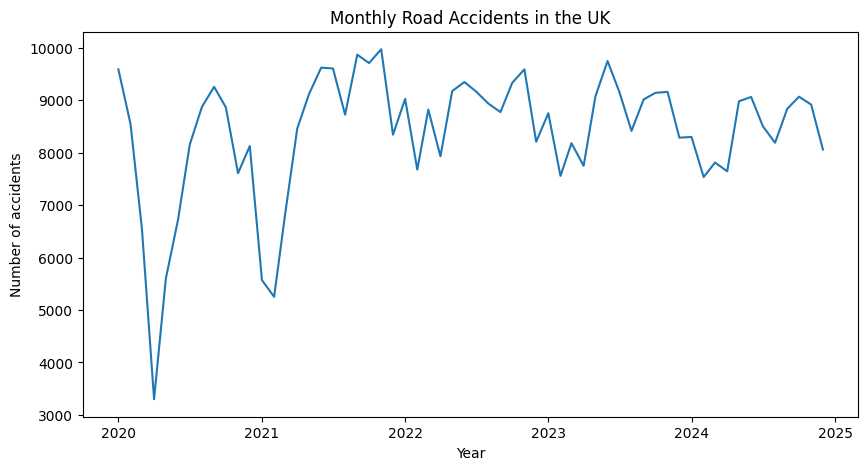

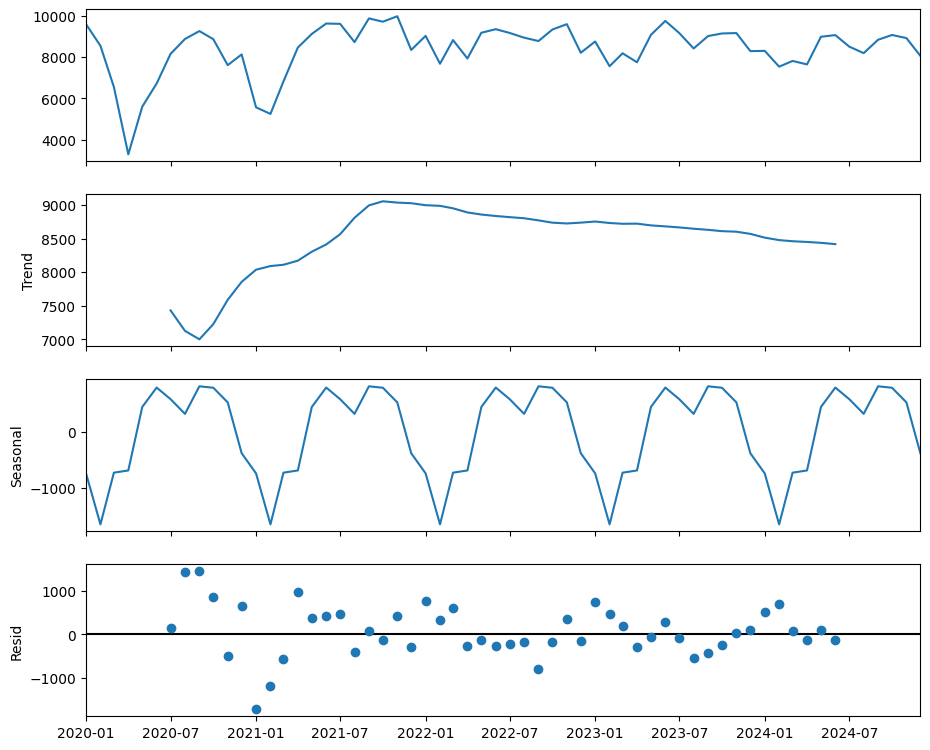

ADF Statistic: -4.788488236475244
p-value: 5.721180469427099e-05


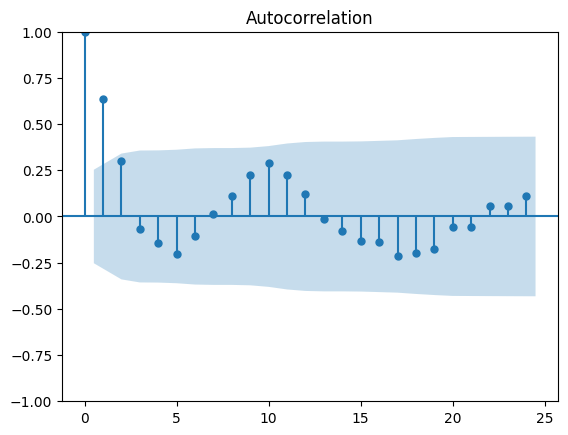

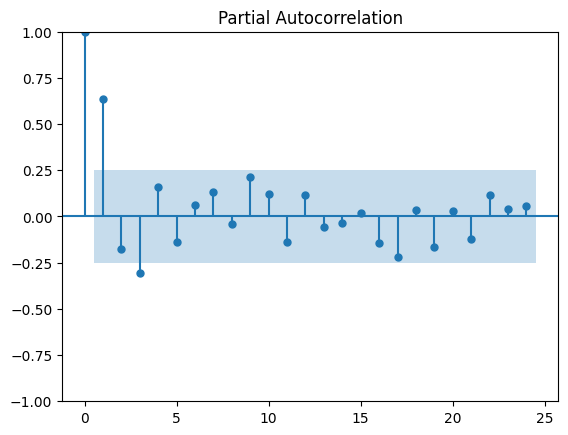

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   60
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -380.219
Date:                            Tue, 19 May 2026   AIC                            766.439
Time:                                    13:16:33   BIC                            771.989
Sample:                                01-01-2020   HQIC                           768.527
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0003      0.016     63.141      0.000       0.969       1.031
ar.S.L12       0.0983      0.083   

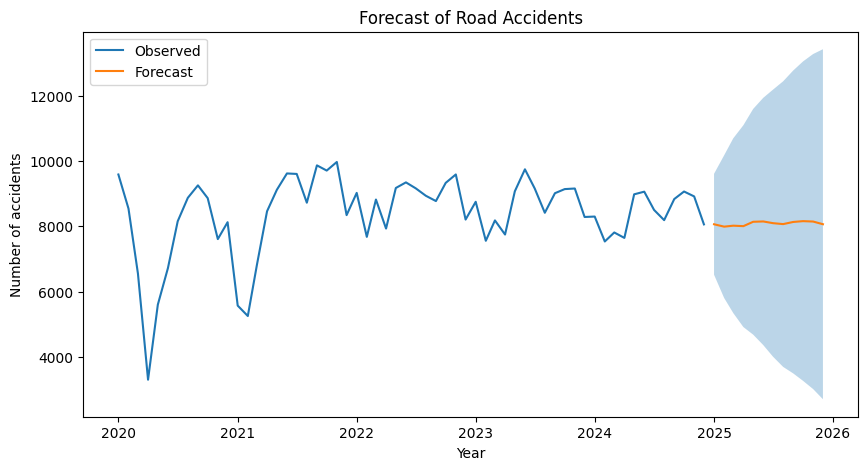

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load data
df = pd.read_csv("dft-road-casualty-statistics-collision-last-5-years.csv")

# Parse dates explicitly: UK data use day/month/year format
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

# Aggregate to monthly accident counts
df['month'] = df['date'].dt.to_period('M')
monthly_accidents = df.groupby('month').size()
monthly_accidents.index = monthly_accidents.index.to_timestamp()


# Plot monthly accident counts
plt.figure(figsize=(10, 5))
plt.plot(monthly_accidents)
plt.title("Monthly Road Accidents in the UK")
plt.xlabel("Year")
plt.ylabel("Number of accidents")
plt.show()


# Seasonal decomposition
decomposition = seasonal_decompose(
    monthly_accidents,
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()


# Augmented Dickey-Fuller test
result = adfuller(monthly_accidents)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


# ACF and PACF plots
plot_acf(monthly_accidents, lags=24)
plt.title("Autocorrelation")
plt.show()

plot_pacf(monthly_accidents, lags=24)
plt.title("Partial Autocorrelation")
plt.show()


# SARIMA model
model = SARIMAX(
    monthly_accidents,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())


# Forecast next 12 months
forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(10, 5))
plt.plot(monthly_accidents, label="Observed")
plt.plot(forecast_mean, label="Forecast")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.legend()
plt.title("Forecast of Road Accidents")
plt.xlabel("Year")
plt.ylabel("Number of accidents")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')